# Player Tracking in Sports - Multi-View Tracking and 3D Reconstruction

## Imports

In [1]:
from src.utils.video import open_video, get_frames, save_video
from src.utils.visualization import show_image, show_hist
from src.tracking.motion_detection import MOG2_motion_detection
from src.tracking.image_processing import opening_closing

## Path Definitions

In [2]:
VIDEOS_DIR = "data/videos"

# Video definitions: each cam
CAMERAS = {
    "cam_13": {
        "video_path": "data/videos/out13.mp4",
    },
    "cam_2": {
        "video_path": "data/videos/out2.mp4",
    },
    "cam_4": {
        "video_path": "data/videos/out4.mp4",
    },
}

## Open Video and Read Frames

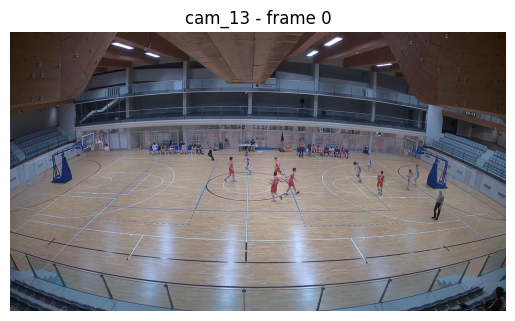

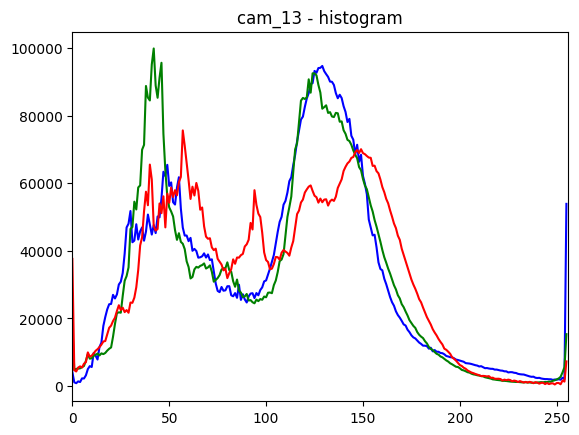

In [3]:
#TODO: EXAMPLE
cap = open_video(CAMERAS["cam_13"]["video_path"])
frames_color, _ = get_frames(cap, max_frames=None)

# Release the video capture object to free resources
cap.release()

show_image(frames_color[0], title="cam_13 - frame 0")
show_hist(frames_color[0], title="cam_13 - histogram")

## Motion Detection

### Mixture of Gaussians (MOG2) Background Subtraction

In [ ]:
# Parameters for MOG2 motion detection
learning_rate = -1  # Use default learning rate (auto-adaptive)
history_length = 300
var_threshold = 20
detect_shadows = True

# Compute motion masks using MOG2
masks = MOG2_motion_detection(frames_color, learning_rate, history_length, var_threshold, detect_shadows)

# Morphological opening and closing to clean up the masks
opening_kernel_size = 5
closing_kernel_size = 7
masks = opening_closing(masks, opening_kernel_size=opening_kernel_size, closing_kernel_size=closing_kernel_size)

# Save results as video
save_video(masks, "results/motion_detection/cam13/cam_13_mog2_masks.mp4")

KeyboardInterrupt: 